In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import metrics
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
data = pd.read_csv("Dataset_ATS_v2.csv")

In [3]:
# ======================== Data Preparation Deliverables =========================
# how many columns and rows in the dataset
rows = data.shape[0]
cols = data.shape[1]
print("\nrows: ", rows)
print("columns: ", cols)



rows:  7043
columns:  10


In [4]:
# Identify categorical and numerical variables
categorical_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = data.select_dtypes(include=["number"]).columns.tolist()
print("\nCategorical variables:\n", categorical_cols)
print("\nNumerical variables:\n", numeric_cols)


Categorical variables:
 ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'Churn']

Numerical variables:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [5]:
# if there are any missing values
print("\nMissing values:")
print(data.isnull().sum())
# handle missing values (just in case)
# for the numerical missing variable, use median
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
# for the object missing variable, use mode
data[categorical_cols] = data[categorical_cols].fillna(data[categorical_cols].mode().iloc[0])



Missing values:
gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64


In [6]:
# duplicate value
print("\nDuplicated values:")
print(data.duplicated().any())
print("\nDuplicate rows:", data.duplicated().sum())
# do we need to delete the duplicated rows? No
# data = data.drop_duplicates().copy()


Duplicated values:
True

Duplicate rows: 302


In [7]:
# Distribution of the target variable (Churn) - check class imbalance
print(data['Churn'].value_counts())
print(data['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


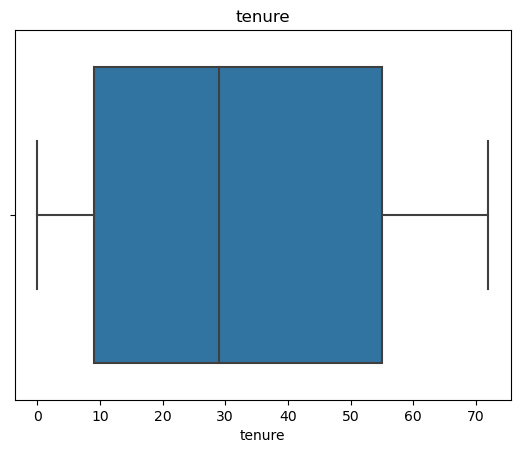

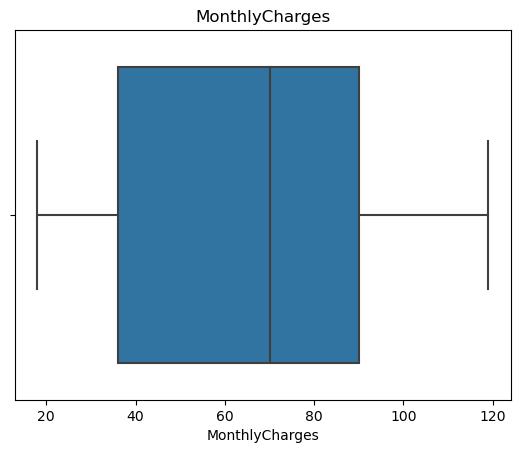

In [8]:
# Box plot - check numeric variable outliers
numeric_cols = ["tenure", "MonthlyCharges"]
for col in numeric_cols:
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [9]:
# IQR - check numeric variable outliers
Q1 = data['tenure'].quantile(0.25)
Q3 = data['tenure'].quantile(0.75)
IQR = Q3 - Q1
print("\nTenure IQR:", IQR)

Q1 = data['MonthlyCharges'].quantile(0.25)
Q3 = data['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
IQR
print("\nMonthly Charges IQR:", IQR)


Tenure IQR: 46.0

Monthly Charges IQR: 54.0


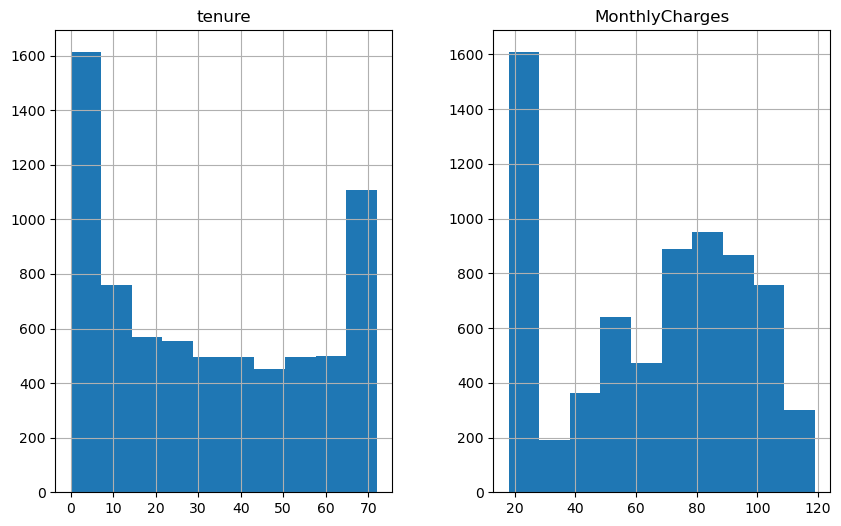

In [10]:
data[numeric_cols].hist(figsize=(10,6))
plt.show()

In [11]:
# the variables in each column
print("\nThe variables in each column:\n")
for col in data.columns:
    print(f"\nColumn: {col}")
    print(data[col].unique())


The variables in each column:


Column: gender
['Female' 'Male']

Column: SeniorCitizen
[0 1]

Column: Dependents
['No' 'Yes']

Column: tenure
[ 1 41 52 67 68 23 72 70 34 28 18 15 11 37 22 46 51  5 45 29 50 27 60 17
 33 66 69 57  8 14 25  7 13 19 59  9  3 10 39 54 35 12 31 53 30 48 38 65
 24 40 43 71 61 26 42 21 56  4  6 55  2 44 62 63 49 20 16 47 32 64 58 36
  0]

Column: PhoneService
['No' 'Yes']

Column: MultipleLines
['No' 'Yes']

Column: InternetService
['DSL' 'Fiber optic']

Column: Contract
['Month-to-month' 'One year' 'Two year']

Column: MonthlyCharges
[ 25  19  76  51  90  77  72 104  20  84  85  95  54  70  89  80 107  68
  60  92  64  21  94 105 101  55  30 114  98  97  75 103 102  66  74  99
  36  91 108  96  82  35  50  45  24  69  53  40  93 106  44  78  65  71
  79  86  26  83  58  46  81  56 109 100  49  57 117  63 112  67  61 110
  88  62  59  52 115 111  34 113  33  48  23  28  42 116  29  73  87  39
  38  32 118 119  31  41  43  27  47  37  18]

Column: Churn
['Yes

In [12]:
# Binary encoding
# Binary categorical variables were encoded using 0/1 mapping.
data["gender"] = data["gender"].map({"Female": 0, "Male": 1})
data["Dependents"] = data["Dependents"].map({"No": 0, "Yes": 1})
data["PhoneService"] = data["PhoneService"].map({"No": 0, "Yes": 1})
data["MultipleLines"] = data["MultipleLines"].map({"No": 0, "Yes": 1})
data["InternetService"] = data["InternetService"].map({
    "DSL": 0,
    "Fiber optic": 1
})
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

In [13]:
# Label encoding
# Label encoding was applied to ordinal categorical variables where a natural order exists.
contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
data["Contract"] = data["Contract"].map(contract_map)

print("\nThe data after encoding:\n")
print(data)



The data after encoding:

      gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0          0              0           0       1             0              0   
1          1              0           0      41             1              0   
2          0              0           1      52             1              0   
3          0              0           0       1             1              0   
4          1              0           0      67             1              0   
...      ...            ...         ...     ...           ...            ...   
7038       1              0           0       1             1              1   
7039       0              0           1      23             1              1   
7040       1              0           1      12             1              0   
7041       1              1           0      12             1              1   
7042       1              0           0      26             1              0   

      Intern

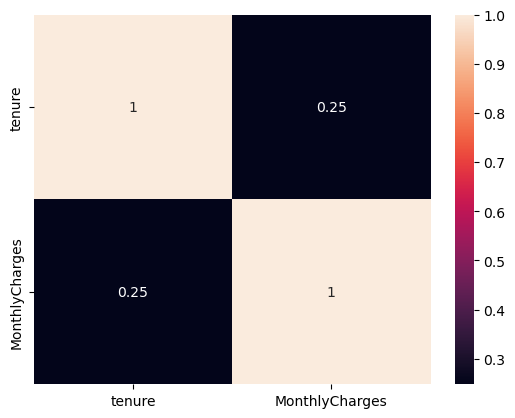

In [14]:
# Check numeric variavble correlation
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True)
plt.show()

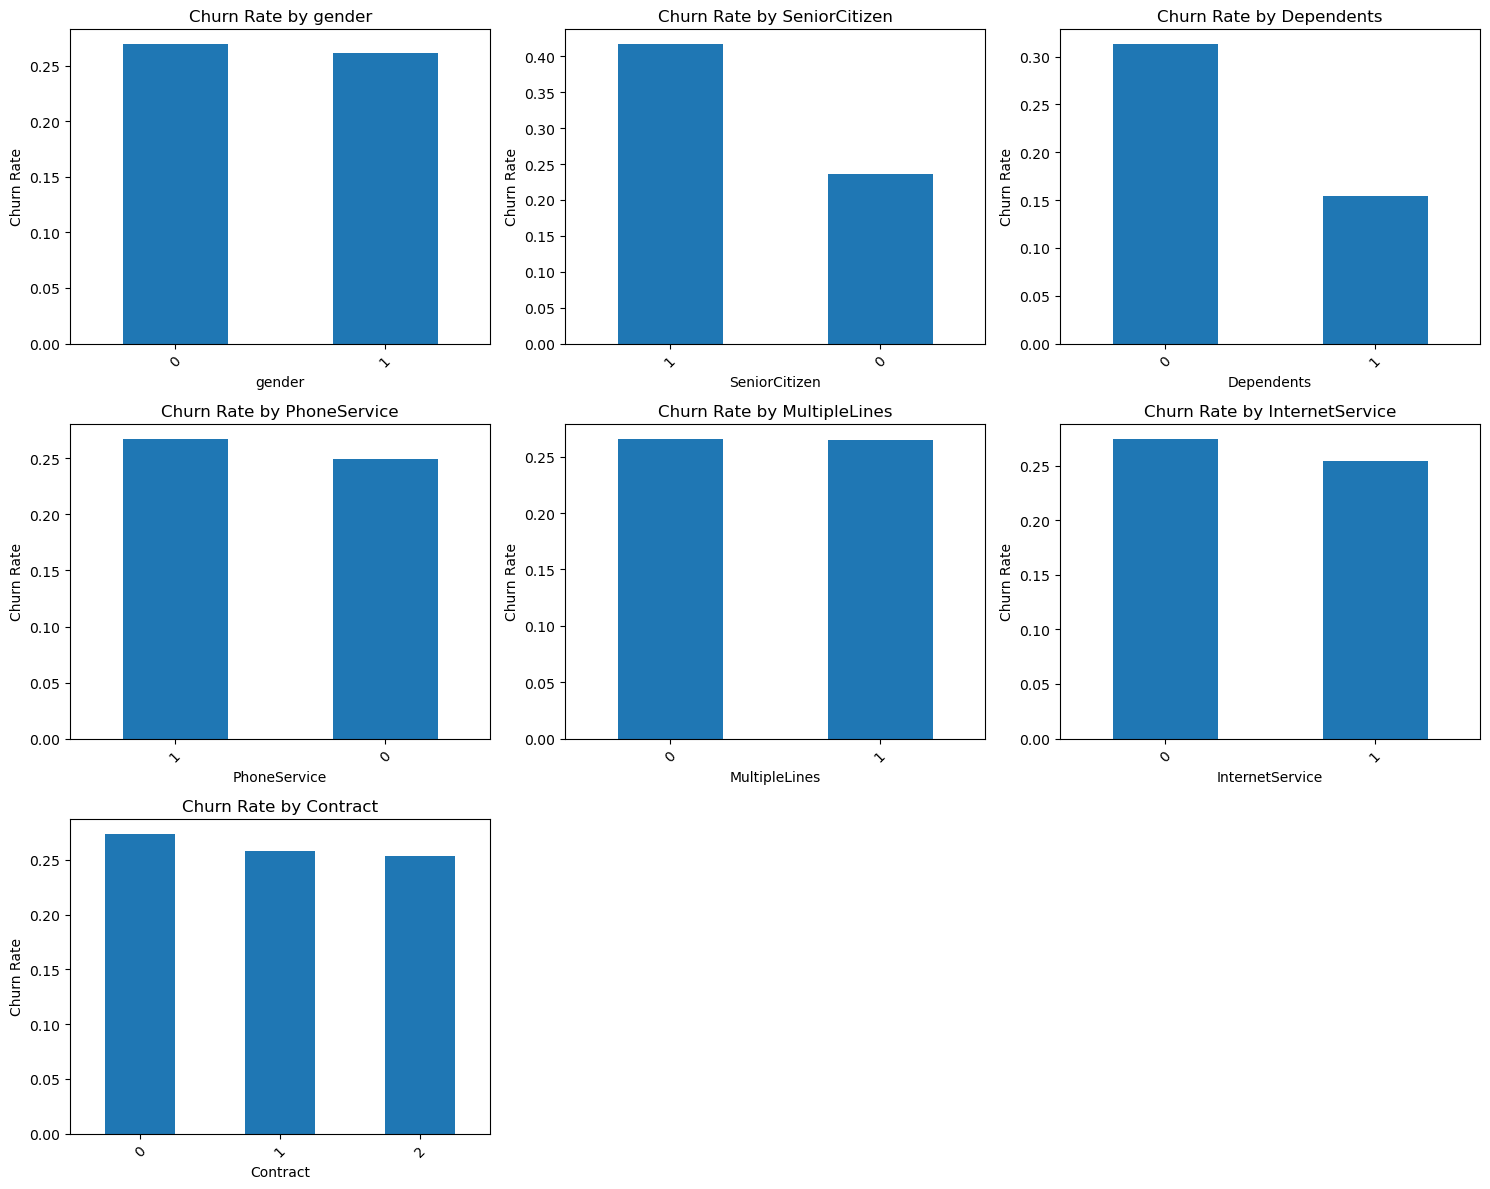

In [15]:
# Check cate variavble vs Churn

categorical_cols = ['gender','SeniorCitizen','Dependents','PhoneService','MultipleLines','InternetService','Contract']
numeric_cols = ['tenure','MonthlyCharges']

if data['Churn'].dtype == 'object':
    data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

# Plot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = data.groupby(col)['Churn'].mean().sort_values(ascending=False)

    churn_rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical_cols), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Impact strength ranking (from strongest to weakest):

⭐ SeniorCitizen (most significant)

⭐ Dependents

Contract (moderate)

Other variables (relatively weak)

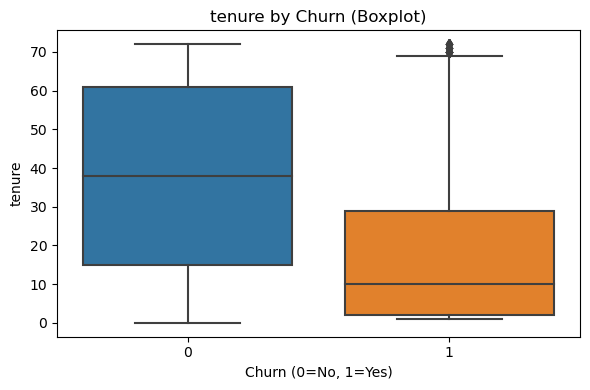

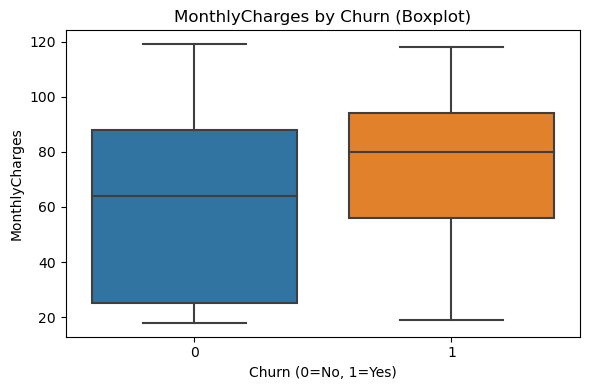

In [16]:
# Check numerical variavble vs Churn
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y=col, data=data)
    plt.title(f"{col} by Churn (Boxplot)")
    plt.xlabel("Churn (0=No, 1=Yes)")
    plt.tight_layout()
    plt.show()

In [17]:
# ================= split dataset into train and test sets ========================
# target and features
X = data.drop(columns=["Churn"])
y = data["Churn"]
# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y
)
print("\nTraining set shape:", X_train.shape)
print("\nTest set shape:", X_test.shape)


Training set shape: (5634, 9)

Test set shape: (1409, 9)


In [18]:
X

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges
0,0,0,0,1,0,0,0,0,25
1,1,0,0,41,1,0,0,1,25
2,0,0,1,52,1,0,0,0,19
3,0,0,0,1,1,0,0,1,76
4,1,0,0,67,1,0,1,0,51
...,...,...,...,...,...,...,...,...,...
7038,1,0,0,1,1,1,0,1,95
7039,0,0,1,23,1,1,1,1,91
7040,1,0,1,12,1,0,0,0,21
7041,1,1,0,12,1,1,1,0,99


In [19]:
# ==================== scaling =========================

# MinMax Method
numeric_cols = ["tenure", "MonthlyCharges"]
scaler = MinMaxScaler()
# normalises all features to the [0,1] range

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Only scaling numeric variable
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

'''
# Standard Scaler
numeric_cols = ["tenure", "MonthlyCharges"]
scaler = StandardScaler()


X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Only scaling numeric variable
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
'''

'\n# Standard Scaler\nnumeric_cols = ["tenure", "MonthlyCharges"]\nscaler = StandardScaler()\n\n\nX_train_scaled = X_train.copy()\nX_test_scaled = X_test.copy()\n\n# Only scaling numeric variable\nX_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])\nX_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])\n'

In [23]:
X_train_scaled

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges
3757,1,0,1,0.013889,1,0,0,2,0.415842
3165,0,0,0,0.416667,1,0,0,1,0.366337
4912,0,1,0,0.638889,1,1,1,0,0.811881
3877,1,0,0,0.597222,1,0,0,1,0.475248
3818,1,0,0,0.013889,1,1,1,2,0.019802
...,...,...,...,...,...,...,...,...,...
6335,0,0,1,0.125000,1,0,0,0,0.366337
6153,1,0,0,0.027778,1,0,0,2,0.356436
4508,1,0,0,0.166667,1,0,0,0,0.386139
2727,1,0,1,0.486111,1,1,1,0,0.019802


In [21]:
#X_test_scaled

In [22]:
# ==================== export train and test =========================

# combine X and y
train_final = X_train_scaled.copy()
train_final["Churn"] = y_train

test_final = X_test_scaled.copy()
test_final["Churn"] = y_test

X_full_scaled = pd.concat([X_train_scaled, X_test_scaled])

# Export
train_final.to_csv("train_scaled.csv", index=False)
test_final.to_csv("test_scaled.csv", index=False)
X_full_scaled.to_csv("X_full_scaled.csv", index=False)